# Mini EDA — Lentiamo (gafas graduadas)

Vistazo rápido del dataset de gafas graduadas para informar el `02_LimpiezaEDA.ipynb`.

Pieza estrella al final: **score unificado de asociación con el precio** — pone categóricas y numéricas en la misma escala (0-1), así sabemos si pesa más la marca o el ancho del cristal.

## 0. Carga y limpieza inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('../data/raw/lentiamo_graduadas.csv')
df = df.drop(columns=['polarizadas', 'tipo'])
df = df.set_index('modelo')
df

,url,marca,genero,material_montura,forma,tipo_montura,color,talla,ancho_lente,ancho_puente,largo_varilla,calibre_total,peso,precio
modelo,,,,,,,,,,,,,,
0RX5698 8109 56,https://www.lentiamo.es/ray-ban-0rx5698-8109-5...,Ray-Ban,Unisex,Acetato,Aviador,Montura completa,Marrón,M,56.0,14.0,145.0,133.0,190.0,112.9
SL 574 001 52,https://www.lentiamo.es/saint-laurent-sl-574-0...,Saint Laurent,Unisex,Pasta,Rectangulares,Montura completa,Negro,M,52.0,21.0,145.0,139.0,155.0,249.9
SL M138 001 55,https://www.lentiamo.es/saint-laurent-sl-m138-...,Saint Laurent,Mujer,Pasta,Cat Eye,Montura completa,Negro,M,55.0,18.0,145.0,138.0,160.0,249.9
0OV5183 1003 45,https://www.lentiamo.es/oliver-peoples-o-malle...,Oliver Peoples,Hombre,Acetato,Redondas,Montura completa,Marrón,S,45.0,22.0,145.0,122.0,230.0,299.9
TH 2268/C 807 19 51,https://www.lentiamo.es/tommy-hilfiger-th-2268...,Tommy Hilfiger,Unisex,Acetato,Cuadradas,Montura completa,Negro,M,51.0,19.0,150.0,133.0,170.0,149.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GG200 GUN 48,https://www.lentiamo.es/germano-gambini-gg200-...,Germano Gambini,Unisex,Metal,Redondas,Montura completa,Gris,M,48.0,21.0,140.0,133.0,155.0,184.9
GG0027O 002 50,https://www.lentiamo.es/gucci-gg0027o-002-50.html,Gucci,Mujer,Pasta,Redondas,Montura completa,Marrón,M,50.0,20.0,140.0,130.0,195.0,189.9
GG0833O 001 55,https://www.lentiamo.es/gucci-gg0833o-001-55.html,Gucci,Hombre,Metal,Aviador,Montura completa,Negro,M,55.0,17.0,145.0,134.0,210.0,309.9


In [3]:
df.isna().sum()

url                   0
marca                 4
genero                4
material_montura      4
forma                 4
tipo_montura          4
color                 8
talla               159
ancho_lente         156
ancho_puente        156
largo_varilla       156
calibre_total       156
peso                  2
precio                1
dtype: int64

In [4]:
df = df.dropna(subset=['precio', 'marca', 'genero', 'color', 'talla'])
print(f'Tras dropna en cols críticas → {len(df)} filas')

Tras dropna en cols críticas → 2712 filas


In [5]:
df['marca'].sort_values().unique()

<StringArray>
[  'Armani Exchange',           'Arnette',        'Balenciaga',            'Barbie',          'Blackfin',            'Bogner',    'Bottega Veneta',          'Burberry',  'Carolina Herrera',
           'Carrera', 'Centrostyle S.p.A',             'Chloé',     'David Beckham',          'Davidoff',            'Disney',   'Dolce & Gabbana',         'Dsquared2',         'Elie Saab',
    'Emporio Armani',            'Esprit',              'Etro',   'Germano Gambini',    'Giorgio Armani',             'Gucci',             'Guess',   'Harley Davidson',      'Harry Potter',
              'Hugo',         'Hugo Boss',    'Indestructible',            'Jaguar',        'Jimmy Choo',        'Kate Spade',           'Lacoste',            'Levi´s',         'M Missoni',
       'Marc Jacobs',          'Max Mara',            'Max&Co',              'Mexx',      'Michael Kors',          'Miraflex',           'Missoni',           'Miu Miu',          'Moschino',
     'Moschino Love',        'Nano V

In [6]:
df[df['marca'] == 'Police']

,url,marca,genero,material_montura,forma,tipo_montura,color,talla,ancho_lente,ancho_puente,largo_varilla,calibre_total,peso,precio
modelo,,,,,,,,,,,,,,
VPL683 0786 57,https://www.lentiamo.es/police-blackbird-ti-1-...,Police,Hombre,Metal/Pasta,Rectangulares,Montura completa,Marrón,M,54.0,15.0,145.0,139.0,110.0,91.92


In [7]:
marcas_por_marca = df['marca'].value_counts()
marcas_por_marca[marcas_por_marca < 10]

marca
Giorgio Armani       9
Paw Patrol           8
Prada Linea Rossa    8
Moschino             8
Under Armour         7
Swarovski            7
Carolina Herrera     7
Max&Co               7
Missoni              7
Elie Saab            6
Ralph Lauren         5
Barbie               5
Bogner               5
Etro                 5
Hugo                 4
Tom Tailor           4
Harry Potter         3
Kate Spade           3
Miraflex             3
Victoria Beckham     2
Lacoste              1
Davidoff             1
Arnette              1
Harley Davidson      1
M Missoni            1
Pierre Cardin        1
Police               1
Tiffany&Co.          1
Name: count, dtype: int64

---
## 1. Distribución del precio (target)

In [8]:
df['precio'].describe().round(2)

count    2712.00
mean      138.56
std        72.79
min        18.89
25%        84.99
50%       113.90
75%       179.90
max       479.90
Name: precio, dtype: float64

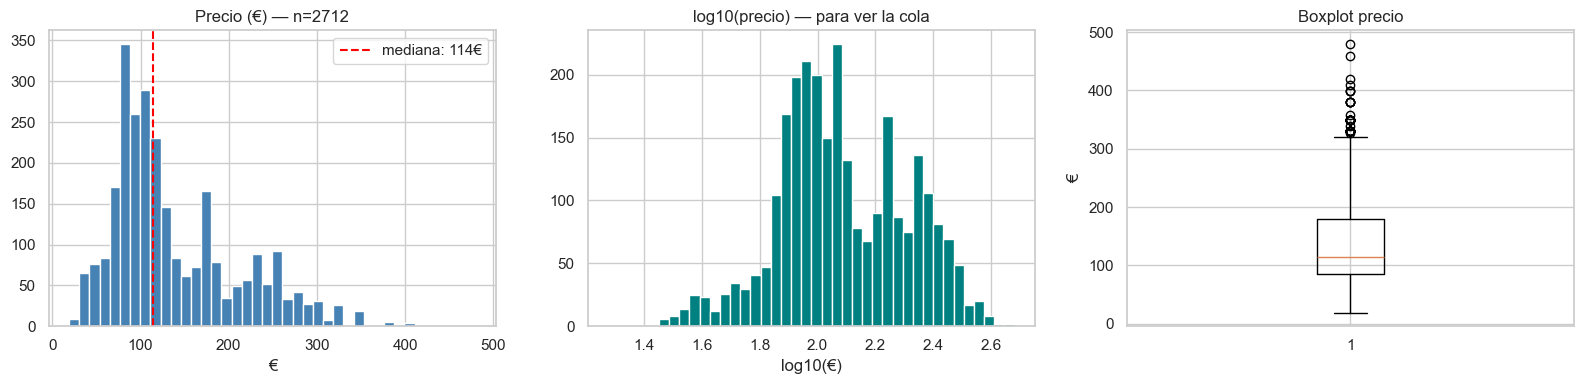

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['precio'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'Precio (€) — n={len(df)}')
axes[0].set_xlabel('€')
axes[0].axvline(df['precio'].median(), color='red', linestyle='--',
                label=f'mediana: {df["precio"].median():.0f}€')
axes[0].legend()

axes[1].hist(np.log10(df['precio']), bins=40, color='teal', edgecolor='white')
axes[1].set_title('log10(precio) — para ver la cola')
axes[1].set_xlabel('log10(€)')

axes[2].boxplot(df['precio'], vert=True)
axes[2].set_title('Boxplot precio')
axes[2].set_ylabel('€')

plt.tight_layout()
plt.show()

**Lectura:** distribución asimétrica con cola larga a la derecha. Si la regresión lineal va flojita, probaremos `log(precio)` como target.

---
## 2. Top marcas y precio por marca

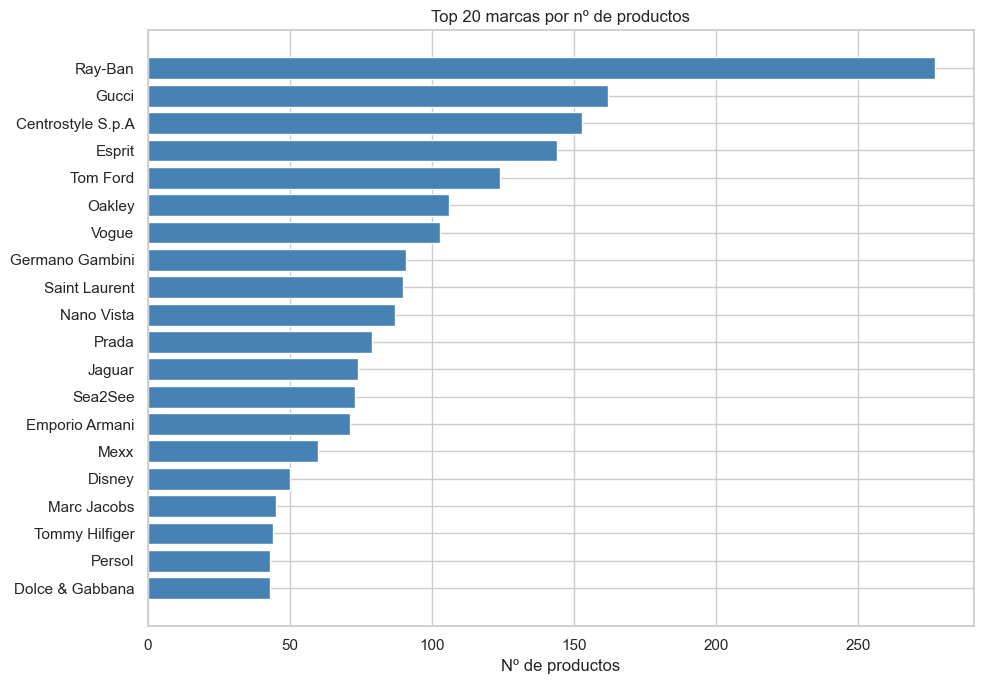

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
top = df['marca'].value_counts().head(20)
ax.barh(top.index[::-1], top.values[::-1], color='steelblue')
ax.set_title('Top 20 marcas por nº de productos')
ax.set_xlabel('Nº de productos')
plt.tight_layout()
plt.show()

In [11]:
top15 = df['marca'].value_counts().head(15).index
tabla_marcas = (df[df['marca'].isin(top15)]
                .groupby('marca')['precio']
                .agg(['count', 'mean', 'median', 'min', 'max'])
                .round(1)
                .sort_values('median', ascending=False))
tabla_marcas

,count,mean,median,min,max
marca,,,,,
Tom Ford,124,260.7,259.9,138.5,419.9
Saint Laurent,90,255.4,259.9,137.9,339.9
Gucci,162,222.4,229.9,88.4,357.9
Prada,79,200.8,214.9,145.9,239.9
Jaguar,74,178.3,189.9,79.1,209.9
Germano Gambini,91,180.6,179.9,179.9,184.9
Oakley,106,119.5,124.9,37.8,249.9
Mexx,60,110.4,119.9,46.8,139.9
Emporio Armani,71,106.8,113.9,36.6,159.9


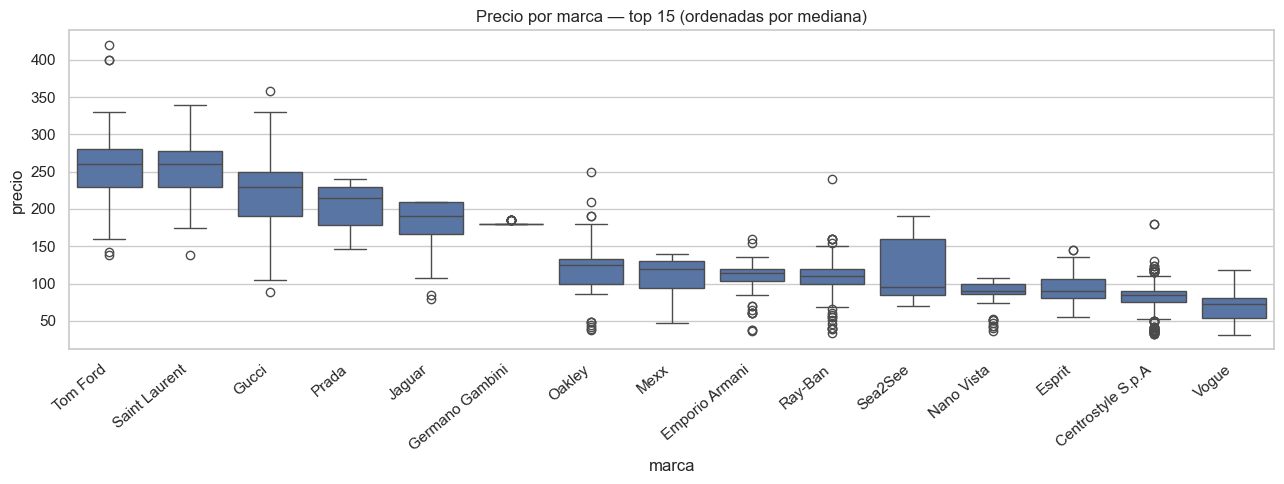

In [12]:
orden = tabla_marcas.index.tolist()
plt.figure(figsize=(13, 5))
sns.boxplot(data=df[df['marca'].isin(top15)], x='marca', y='precio', order=orden)
plt.title('Precio por marca — top 15 (ordenadas por mediana)')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Distribuciones categóricas

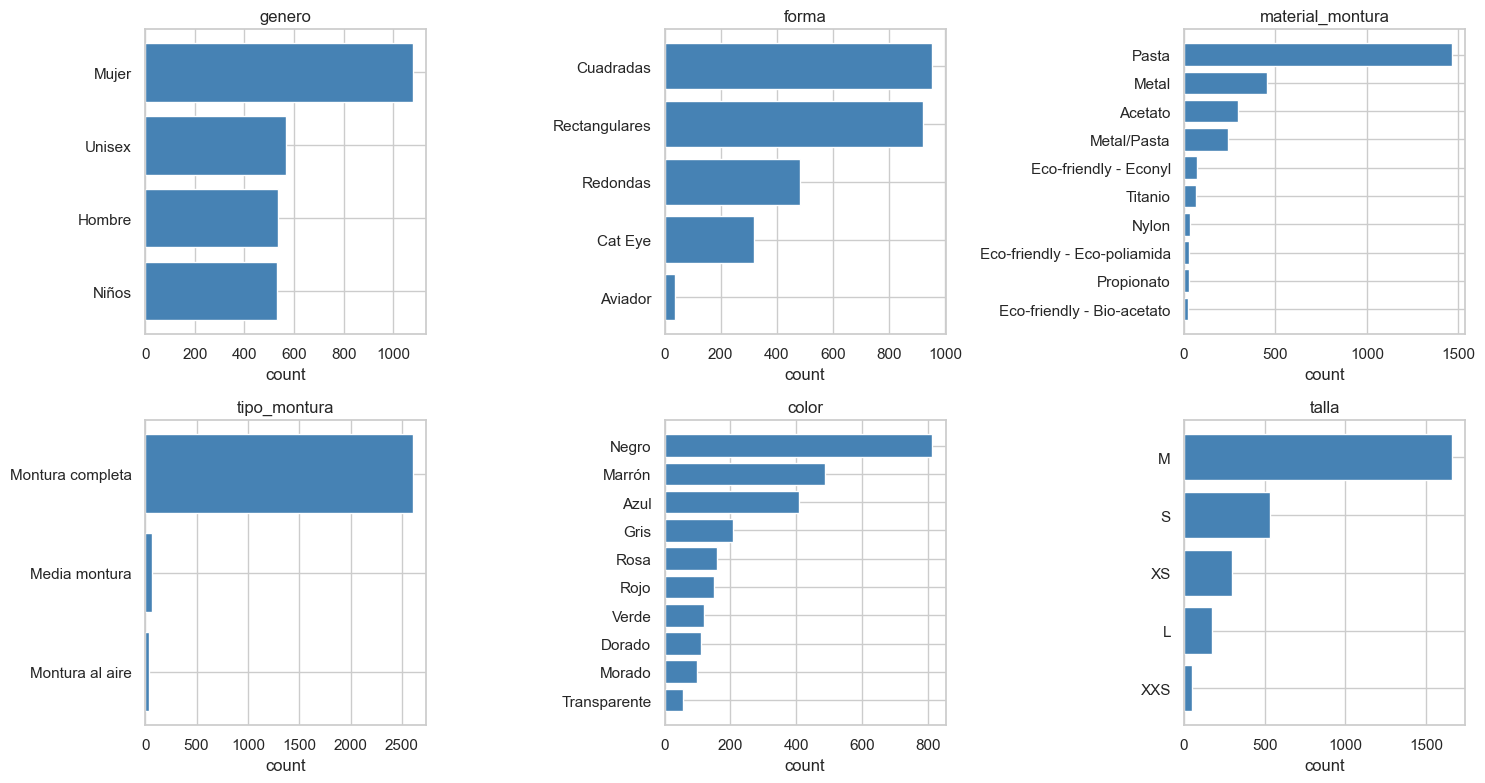

In [13]:
categoricas = ['genero', 'forma', 'material_montura', 'tipo_montura', 'color', 'talla']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, categoricas):
    vc = df[col].value_counts().head(10)
    ax.barh(vc.index[::-1], vc.values[::-1], color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('count')
plt.tight_layout()
plt.show()

In [14]:
card = pd.DataFrame({
    'columna':   categoricas,
    'únicos':    [df[c].nunique() for c in categoricas],
    'top_valor': [df[c].mode().iloc[0] if not df[c].mode().empty else None for c in categoricas],
    'freq_top':  [df[c].value_counts().iloc[0] for c in categoricas],
})
card['% top'] = (card['freq_top'] / len(df) * 100).round(1)
card

,columna,únicos,top_valor,freq_top,% top
0,genero,4,Mujer,1079,39.8
1,forma,5,Cuadradas,955,35.2
2,material_montura,12,Pasta,1463,53.9
3,tipo_montura,3,Montura completa,2606,96.1
4,color,15,Negro,814,30.0
5,talla,5,M,1659,61.2


---
## 4. Precio por categórica (boxplots)

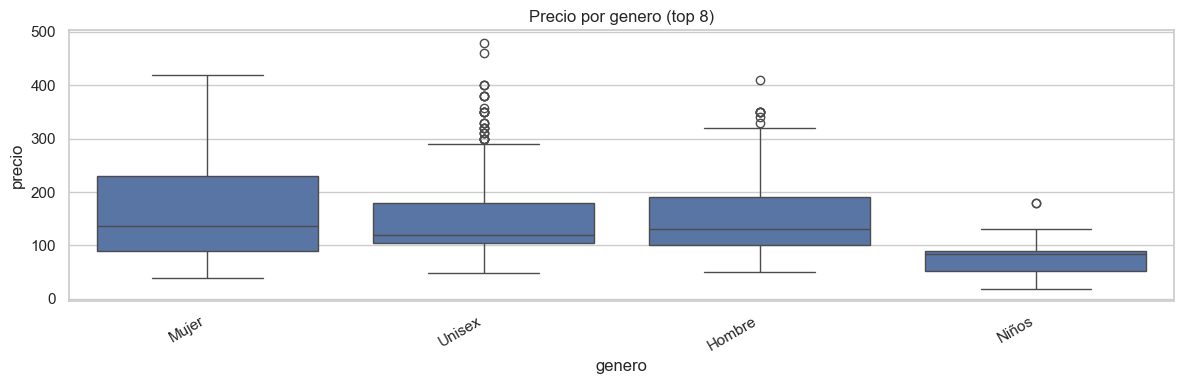

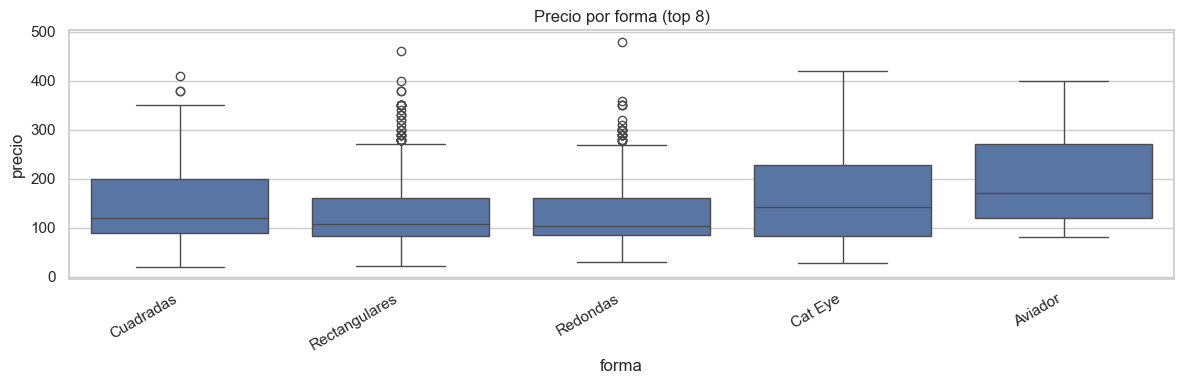

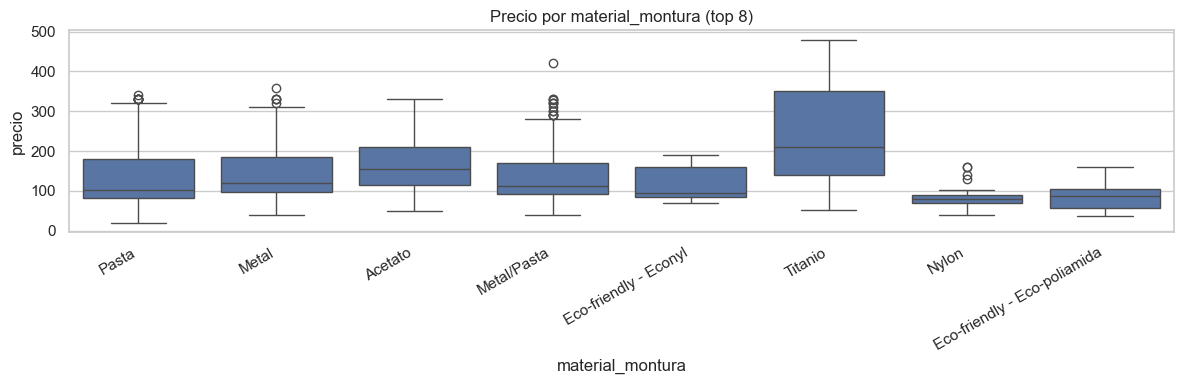

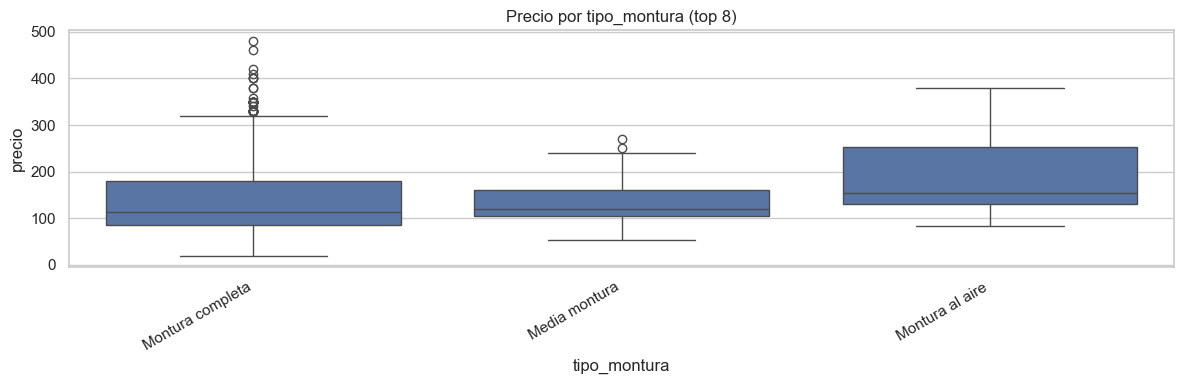

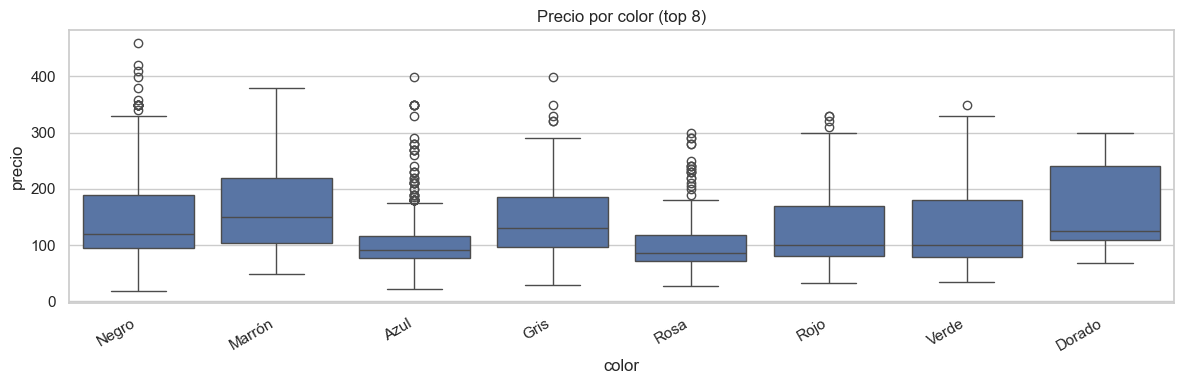

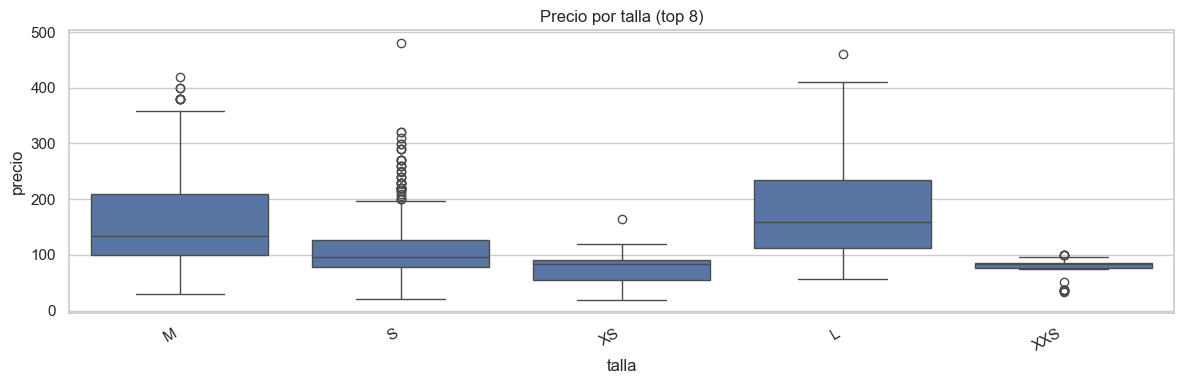

In [15]:
def boxplot_top(df, col, top_n=8):
    top_cats = df[col].value_counts().head(top_n).index.tolist()
    sub = df[df[col].isin(top_cats)]
    plt.figure(figsize=(12, 4))
    sns.boxplot(data=sub, x=col, y='precio', order=top_cats)
    plt.title(f'Precio por {col} (top {top_n})')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

for col in categoricas:
    boxplot_top(df, col)

---
## 5. Correlación entre numéricas

In [16]:
num_cols = ['ancho_lente', 'ancho_puente', 'largo_varilla', 'calibre_total', 'peso', 'precio']
df_num = df[num_cols].copy()
df_num.describe().round(2)

,ancho_lente,ancho_puente,largo_varilla,calibre_total,peso,precio
count,2712.00,2712.00,2712.00,2712.00,2712.00,2712.00
mean,51.76,17.38,139.92,130.63,156.04,138.56
std,3.75,1.98,6.92,8.58,71.01,72.79
min,20.00,9.00,105.00,89.00,40.00,18.89
25%,50.00,16.00,140.00,128.00,100.00,84.99
50%,53.00,17.00,140.00,133.00,155.00,113.90
75%,54.00,19.00,145.00,136.00,190.00,179.90
max,61.00,25.00,169.00,150.00,565.00,479.90


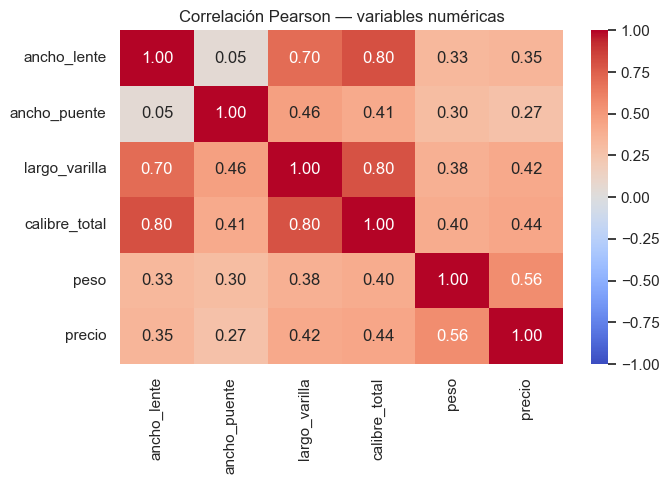

In [17]:
plt.figure(figsize=(7, 5))
corr = df_num.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación Pearson — variables numéricas')
plt.tight_layout()
plt.show()

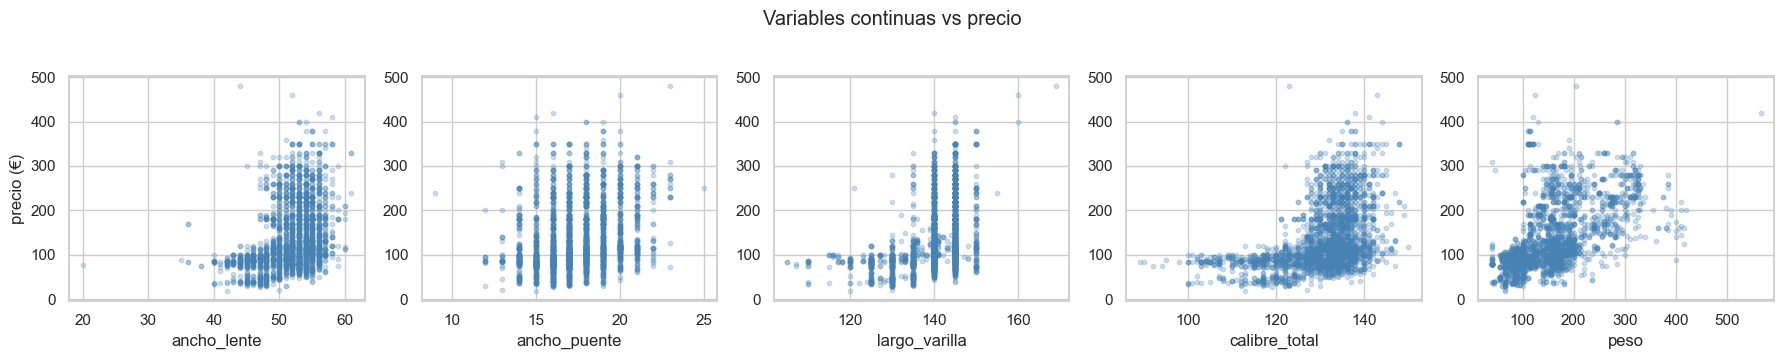

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, c in zip(axes, ['ancho_lente', 'ancho_puente', 'largo_varilla', 'calibre_total', 'peso']):
    sub = df[[c, 'precio']].dropna()
    ax.scatter(sub[c], sub['precio'], alpha=0.25, s=10, color='steelblue')
    ax.set_xlabel(c)
    if ax is axes[0]:
        ax.set_ylabel('precio (€)')
plt.suptitle('Variables continuas vs precio', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. ⭐ Fuerza de asociación con el precio (todas las variables)

Aquí está la pieza clave. Necesitamos comparar variables **categóricas** (marca, color, forma…) con variables **numéricas** (ancho_lente, peso…). Pearson NO sirve para categóricas, así que:

- **Numérica → precio:** uso **r²** (Pearson al cuadrado = fracción de varianza explicada).
- **Categórica → precio:** uso **η² (correlation ratio)** = la varianza del precio que se explica al saber a qué grupo pertenece cada producto.

Ambas métricas viven en **[0, 1]** y son directamente comparables (las dos son R² de algún tipo). Score 0 = la variable no influye en el precio. Score 1 = lo determina al 100 %.

In [19]:
def correlation_ratio(categorias, valores):
    """η² — fracción de varianza de `valores` explicada por la categoría.
    Usar para cat → num.
    """
    cats = pd.Categorical(categorias)
    valores = pd.Series(valores).reset_index(drop=True)
    codes = pd.Series(cats.codes).reset_index(drop=True)
    valid = valores.notna() & (codes >= 0)
    if valid.sum() < 2:
        return np.nan
    valores = valores[valid].values
    codes = codes[valid].values
    overall = valores.mean()
    ss_total = ((valores - overall) ** 2).sum()
    if ss_total == 0:
        return 0.0
    ss_between = 0.0
    for code in np.unique(codes):
        grp = valores[codes == code]
        if len(grp) > 0:
            ss_between += len(grp) * (grp.mean() - overall) ** 2
    return ss_between / ss_total


def cramers_v(x, y):
    """Cramér's V (cat ↔ cat) en [0, 1]. 0=independentes, 1=asociadas."""
    confusion = pd.crosstab(x, y)
    if confusion.size == 0:
        return np.nan
    chi2 = stats.chi2_contingency(confusion, correction=False)[0]
    n = confusion.values.sum()
    if n == 0:
        return np.nan
    phi2 = chi2 / n
    r, k = confusion.shape
    denom = min(k - 1, r - 1)
    return np.nan if denom <= 0 else min(1.0, np.sqrt(phi2 / denom))


print('Funciones definidas: correlation_ratio (cat→num), cramers_v (cat↔cat).')

Funciones definidas: correlation_ratio (cat→num), cramers_v (cat↔cat).


In [20]:
# Variables a evaluar (todas menos url, que es metadato)
cat_cols = ['marca', 'genero', 'material_montura', 'forma', 'tipo_montura', 'color', 'talla']
num_cols_features = ['ancho_lente', 'ancho_puente', 'largo_varilla', 'calibre_total', 'peso']

scores = {}

# Numéricas → r² con precio
for c in num_cols_features:
    sub = df[[c, 'precio']].dropna()
    if len(sub) < 2:
        scores[c] = np.nan
    else:
        r = sub[c].corr(sub['precio'])
        scores[c] = r ** 2

# Categóricas → η² con precio
for c in cat_cols:
    sub = df[[c, 'precio']].dropna()
    scores[c] = correlation_ratio(sub[c], sub['precio'])

scores_df = (pd.Series(scores, name='asociación con precio')
             .sort_values(ascending=False)
             .round(3))
scores_df

marca               0.815
peso                0.312
calibre_total       0.191
genero              0.186
talla               0.184
largo_varilla       0.174
ancho_lente         0.119
color               0.093
material_montura    0.088
ancho_puente        0.074
forma               0.032
tipo_montura        0.008
Name: asociación con precio, dtype: float64

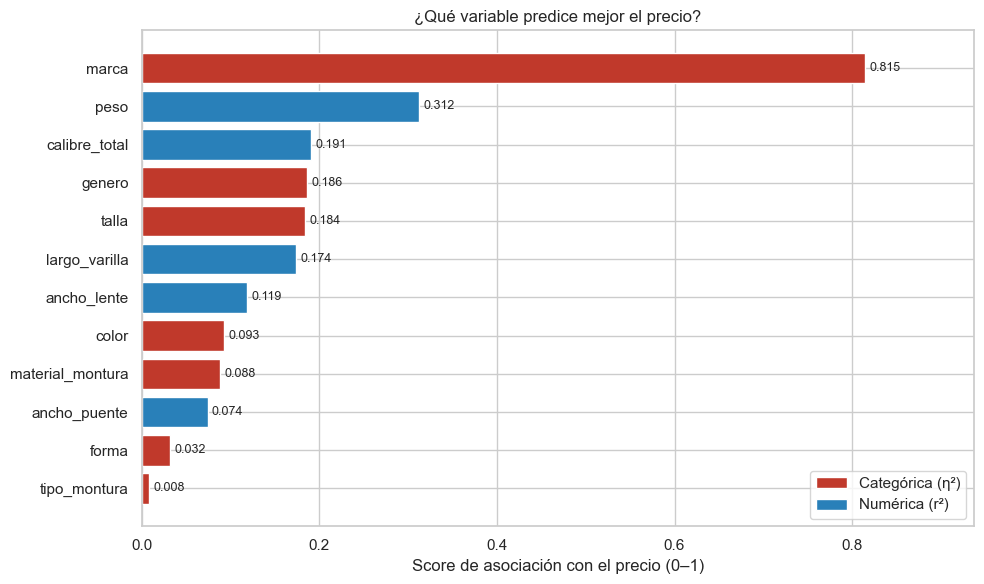

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#c0392b' if v in cat_cols else '#2980b9' for v in scores_df.index]
ax.barh(scores_df.index[::-1], scores_df.values[::-1], color=colores[::-1])
ax.set_xlabel('Score de asociación con el precio (0–1)')
ax.set_title('¿Qué variable predice mejor el precio?')
ax.set_xlim(0, max(0.05, scores_df.max() * 1.15))
for i, v in enumerate(scores_df.values[::-1]):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#c0392b', label='Categórica (η²)'),
    Patch(facecolor='#2980b9', label='Numérica (r²)'),
], loc='lower right')
plt.tight_layout()
plt.show()

**Cómo leer este gráfico:**
- Las variables de arriba son las que **más explican el precio** → las que más debería usar el modelo.
- Las de abajo apenas mueven la aguja → candidatas a descartar (o a combinar con feature engineering).
- **Aviso:** η² puede sobrestimarse cuando hay muchas categorías con pocas muestras (`marca` tiene 75 categorías). En el modelo final usaremos validación cruzada para confirmar.

---
## 7. Heatmap todas-vs-todas

Útil para detectar **redundancias entre features** (multicolinealidad). Si dos columnas se asocian fuertemente (>0.7) puede que aporten la misma información y nos sobre una.

Métrica unificada en `[0, 1]`:
- num × num → `|Pearson|`
- cat × num → `√η²`
- cat × cat → Cramér's V

In [22]:
todas = num_cols_features + cat_cols + ['precio']
matriz = pd.DataFrame(index=todas, columns=todas, dtype=float)

for a in todas:
    for b in todas:
        if a == b:
            matriz.loc[a, b] = 1.0
            continue
        a_num = a in num_cols_features or a == 'precio'
        b_num = b in num_cols_features or b == 'precio'
        sub = df[[a, b]].dropna()
        if len(sub) < 2:
            matriz.loc[a, b] = np.nan
            continue
        if a_num and b_num:
            matriz.loc[a, b] = abs(sub[a].corr(sub[b]))
        elif (not a_num) and (not b_num):
            matriz.loc[a, b] = cramers_v(sub[a], sub[b])
        elif (not a_num) and b_num:
            matriz.loc[a, b] = np.sqrt(correlation_ratio(sub[a], sub[b]))
        else:  # a_num, no b_num
            matriz.loc[a, b] = np.sqrt(correlation_ratio(sub[b], sub[a]))

matriz = matriz.astype(float).round(2)
matriz

,ancho_lente,ancho_puente,largo_varilla,calibre_total,peso,marca,genero,material_montura,forma,tipo_montura,color,talla,precio
ancho_lente,1.00,0.05,0.70,0.80,0.33,0.72,0.75,0.26,0.43,0.18,0.38,0.78,0.35
ancho_puente,0.05,1.00,0.46,0.41,0.30,0.52,0.42,0.31,0.32,0.02,0.26,0.40,0.27
largo_varilla,0.70,0.46,1.00,0.80,0.38,0.77,0.80,0.30,0.17,0.08,0.42,0.80,0.42
calibre_total,0.80,0.41,0.80,1.00,0.40,0.76,0.78,0.33,0.23,0.08,0.42,0.94,0.44
peso,0.33,0.30,0.38,0.40,1.00,0.92,0.43,0.36,0.18,0.05,0.28,0.41,0.56
marca,0.72,0.52,0.77,0.76,0.92,1.00,0.72,0.52,0.32,0.26,0.25,0.46,0.90
genero,0.75,0.42,0.80,0.78,0.43,0.72,1.00,0.26,0.31,0.17,0.32,0.48,0.43
material_montura,0.26,0.31,0.30,0.33,0.36,0.52,0.26,1.00,0.12,0.27,0.18,0.17,0.30
forma,0.43,0.32,0.17,0.23,0.18,0.32,0.31,0.12,1.00,0.13,0.18,0.15,0.18
tipo_montura,0.18,0.02,0.08,0.08,0.05,0.26,0.17,0.27,0.13,1.00,0.20,0.06,0.09


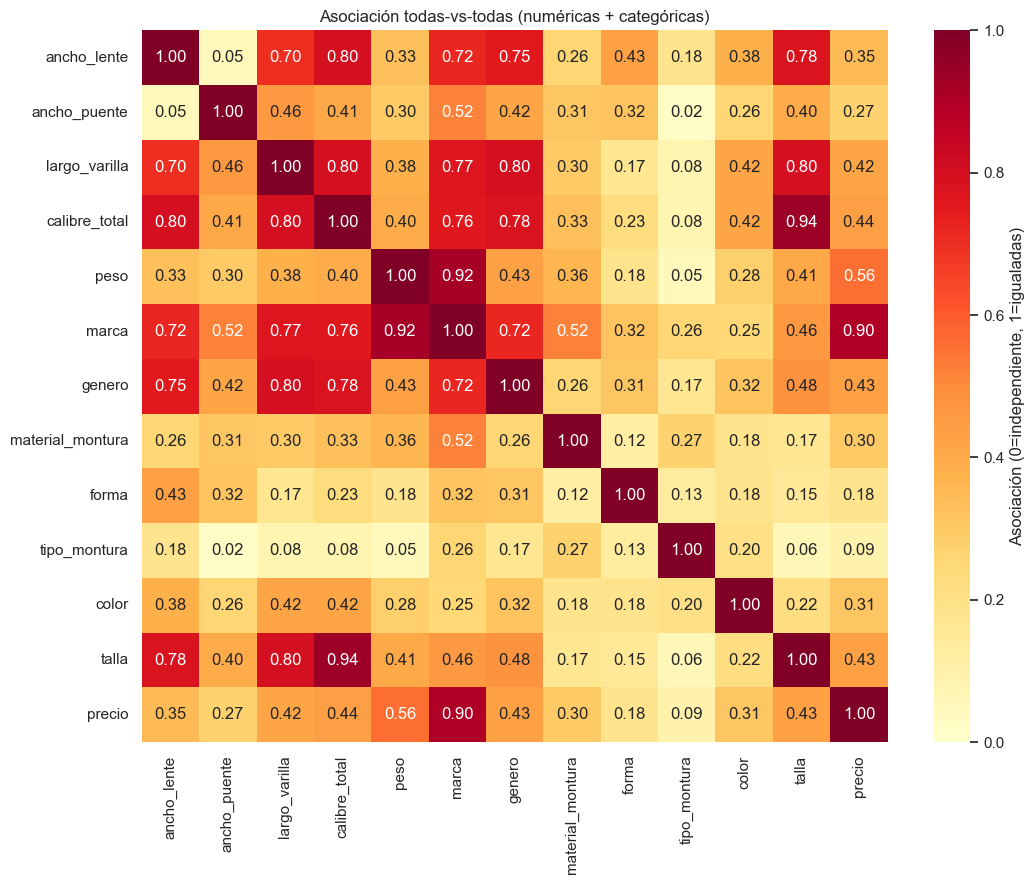

In [23]:
plt.figure(figsize=(11, 9))
sns.heatmap(matriz, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
            cbar_kws={'label': 'Asociación (0=independiente, 1=igualadas)'})
plt.title('Asociación todas-vs-todas (numéricas + categóricas)')
plt.tight_layout()
plt.show()

In [25]:
# Detectar pares feature-feature muy redundantes (>0.7)
redundantes = []
for i, a in enumerate(todas):
    if a == 'precio':
        continue
    for b in todas[i+1:]:
        if b == 'precio':
            continue
        v = matriz.loc[a, b]
        if pd.notna(v) and v > 0.7:
            redundantes.append((a, b, v))

if redundantes:
    print('⚠ Pares con asociación > 0.7 (candidatos a colapsar / eliminar uno):')
    for a, b, v in sorted(redundantes, key=lambda x: -x[2]):
        print(f'  · {a:<20} ↔ {b:<20}  {v:.2f}')
else:
    print('✅ Sin redundancias fuertes entre features.')

⚠ Pares con asociación > 0.7 (candidatos a colapsar / eliminar uno):
  · calibre_total        ↔ talla                 0.94
  · peso                 ↔ marca                 0.92
  · ancho_lente          ↔ calibre_total         0.80
  · largo_varilla        ↔ calibre_total         0.80
  · largo_varilla        ↔ genero                0.80
  · largo_varilla        ↔ talla                 0.80
  · ancho_lente          ↔ talla                 0.78
  · calibre_total        ↔ genero                0.78
  · largo_varilla        ↔ marca                 0.77
  · calibre_total        ↔ marca                 0.76
  · ancho_lente          ↔ genero                0.75
  · ancho_lente          ↔ marca                 0.72
  · marca                ↔ genero                0.72


---
## 8. Resumen — qué llevarse al `02_LimpiezaEDA`

1. **Variables más predictivas** (sec. 6) → se conservan tal cual.
2. **Variables con score < 0.05** → candidatas a eliminar o transformar (feature engineering).
3. **Pares redundantes** (sec. 7) → eliminar uno de cada par para evitar multicolinealidad.
4. **Marcas con `<10` productos** → agrupar en `"Otras"` (28 marcas).
5. **Color con alta cardinalidad** → agrupar en colores básicos (Negro, Marrón, Gris, Azul, Otros).
6. **NaN en medidas (`~5%` filas)** → imputar por mediana de marca/forma.
7. **Target asimétrico** → probar `log(precio)` y comparar.

In [26]:
# Resumen automático
print('=== Resumen GRADUADAS ===')
print(f'  Filas:                         {len(df)}')
print(f'  Marcas únicas:                 {df["marca"].nunique()}')
print(f'  Marcas con <10 productos:      {(df["marca"].value_counts() < 10).sum()}')
print(f'  Precio mediano:                {df["precio"].median():.2f} €')
print(f'  Precio min / max:              {df["precio"].min():.2f} / {df["precio"].max():.2f} €')
print(f'  Cobertura media (no-NaN):      {df.notna().mean().mean()*100:.1f} %')
print()
print('Top 5 features más predictivas del precio:')
for k, v in scores_df.head().items():
    tipo = 'cat' if k in cat_cols else 'num'
    print(f'  · {k:<20} ({tipo}): {v:.3f}')

=== Resumen GRADUADAS ===
  Filas:                         2712
  Marcas únicas:                 75
  Marcas con <10 productos:      28
  Precio mediano:                113.90 €
  Precio min / max:              18.89 / 479.90 €
  Cobertura media (no-NaN):      100.0 %

Top 5 features más predictivas del precio:
  · marca                (cat): 0.815
  · peso                 (num): 0.312
  · calibre_total        (num): 0.191
  · genero               (cat): 0.186
  · talla                (cat): 0.184
